In [7]:
import os
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# Settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [10]:
dataset_path = "C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

print(train_path)
print(test_path)
print(val_path)

C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\train
C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\test
C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\val


In [11]:
print("Train Classes :", os.listdir(r"C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\train"))
print("Test Classes :", os.listdir(r"C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\test"))
print("Validation Classes :", os.listdir(r"C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\val"))

Train Classes : ['NORMAL', 'PNEUMONIA']
Test Classes : ['NORMAL', 'PNEUMONIA']
Validation Classes : ['NORMAL', 'PNEUMONIA']


In [12]:
def count_images(folder):

    image_count = {}

    for cls in os.listdir(folder):

        class_path = os.path.join(folder, cls)

        image_count[cls] = len(os.listdir(class_path))

    return image_count

train_counts = count_images(r"C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\train")
test_counts = count_images(r"C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\test")
val_counts = count_images(r"C:\MediVisionAI\datasets\Chest X-Ray Images\chest_xray\val")

print("Training Dataset")
print(train_counts)

print("\nTesting Dataset")
print(test_counts)

print("\nValidation Dataset")
print(val_counts)

Training Dataset
{'NORMAL': 1341, 'PNEUMONIA': 3875}

Testing Dataset
{'NORMAL': 234, 'PNEUMONIA': 390}

Validation Dataset
{'NORMAL': 8, 'PNEUMONIA': 8}


In [13]:
summary = pd.DataFrame({

    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts

})

summary["Total"] = summary.sum(axis=1)

summary

,Train,Validation,Test,Total
NORMAL,1341,8,234,1583
PNEUMONIA,3875,8,390,4273


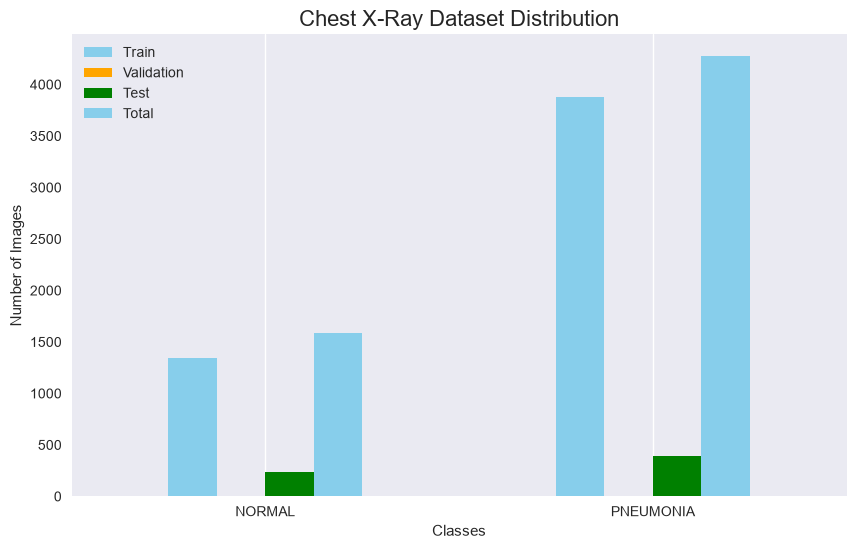

In [14]:
summary.plot(

    kind="bar",
    figsize=(10,6),
    color=["skyblue","orange","green"]

)

plt.title("Chest X-Ray Dataset Distribution", fontsize=16)

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

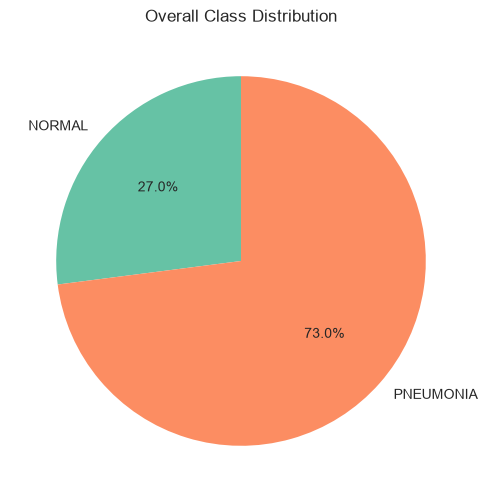

In [15]:
plt.figure(figsize=(6,6))

plt.pie(

    summary["Total"],
    labels=summary.index,
    autopct="%1.1f%%",
    startangle=90

)

plt.title("Overall Class Distribution")

plt.show()

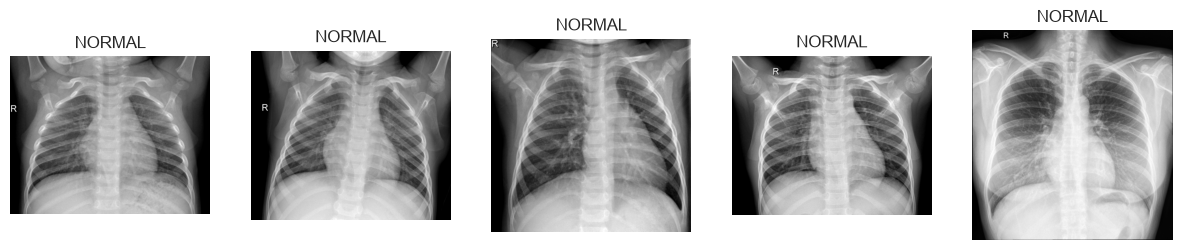

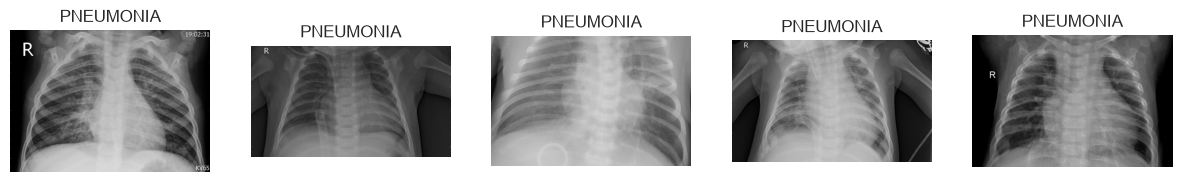

In [16]:
def show_random_images(folder, class_name, n=5):

    class_path = os.path.join(folder, class_name)

    images = random.sample(os.listdir(class_path), n)

    plt.figure(figsize=(15,3))

    for i, image in enumerate(images):

        img = Image.open(os.path.join(class_path, image))

        plt.subplot(1,n,i+1)

        plt.imshow(img, cmap="gray")

        plt.title(class_name)

        plt.axis("off")

    plt.show()

show_random_images(train_path,"NORMAL")

show_random_images(train_path,"PNEUMONIA")

In [17]:
widths = []
heights = []

for cls in os.listdir(train_path):

    class_path = os.path.join(train_path, cls)

    for image in os.listdir(class_path):

        img = Image.open(os.path.join(class_path,image))

        widths.append(img.size[0])

        heights.append(img.size[1])

print("Minimum Width :",min(widths))
print("Maximum Width :",max(widths))

print("Minimum Height :",min(heights))
print("Maximum Height :",max(heights))

Minimum Width : 384
Maximum Width : 2916
Minimum Height : 127
Maximum Height : 2663


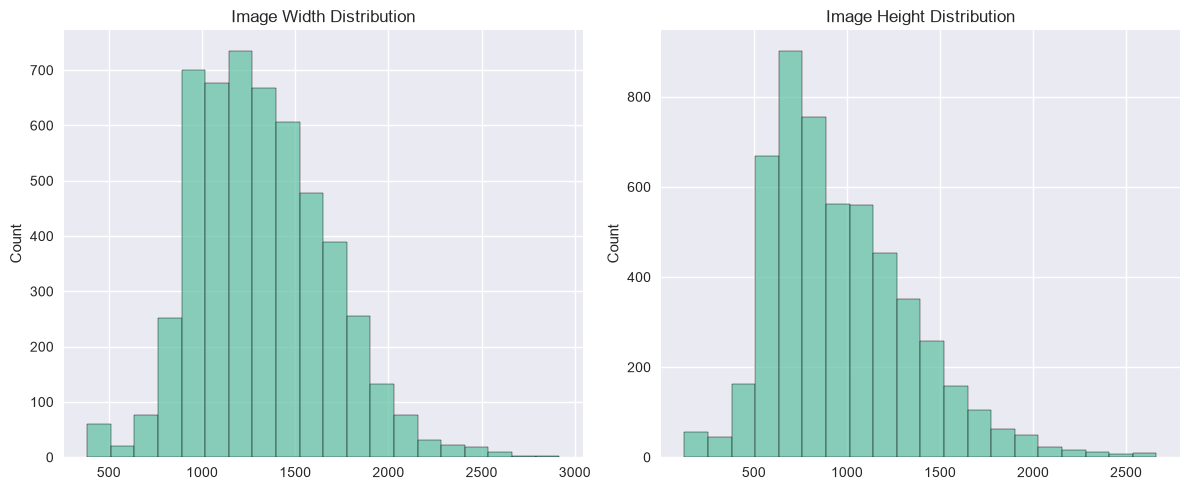

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(widths,bins=20)

plt.title("Image Width Distribution")

plt.subplot(1,2,2)

sns.histplot(heights,bins=20)

plt.title("Image Height Distribution")

plt.tight_layout()

plt.show()

In [19]:
modes = []

for cls in os.listdir(train_path):

    class_path = os.path.join(train_path, cls)

    for image in os.listdir(class_path):

        img = Image.open(os.path.join(class_path,image))

        modes.append(img.mode)

pd.Series(modes).value_counts()

L      4933
RGB     283
Name: count, dtype: int64

In [20]:
corrupted = []

for cls in os.listdir(train_path):

    class_path = os.path.join(train_path, cls)

    for image in os.listdir(class_path):

        try:

            img = Image.open(os.path.join(class_path,image))

            img.verify()

        except:

            corrupted.append(image)

print("Corrupted Images :",len(corrupted))

Corrupted Images : 0


In [21]:
import hashlib

hashes = {}
duplicates = []

for cls in os.listdir(train_path):

    class_path = os.path.join(train_path, cls)

    for image in os.listdir(class_path):

        path = os.path.join(class_path,image)

        with open(path,"rb") as f:

            filehash = hashlib.md5(f.read()).hexdigest()

        if filehash in hashes:

            duplicates.append(path)

        else:

            hashes[filehash]=path

print("Duplicate Images :",len(duplicates))

Duplicate Images : 26


In [22]:
print("="*60)

print("CHEST X-RAY DATASET REPORT")

print("="*60)

print(summary)

print()

print(f"Total Images : {summary['Total'].sum()}")

print(f"Duplicate Images : {len(duplicates)}")

print(f"Corrupted Images : {len(corrupted)}")

print(f"Image Width Range : {min(widths)} - {max(widths)}")

print(f"Image Height Range : {min(heights)} - {max(heights)}")

print("="*60)

CHEST X-RAY DATASET REPORT
           Train  Validation  Test  Total
NORMAL      1341           8   234   1583
PNEUMONIA   3875           8   390   4273

Total Images : 5856
Duplicate Images : 26
Corrupted Images : 0
Image Width Range : 384 - 2916
Image Height Range : 127 - 2663
